In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
print("Libraries loaded ✅")

Libraries loaded ✅


In [8]:
df = pd.read_csv("wtbdata_245days.csv")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (4727520, 13)

First 5 rows:


,TurbID,Day,Tmstamp,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv
0,1,1,00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,00:10,6.17,-3.99,30.73,41.80,25.92,1.0,1.0,1.0,-0.25,494.66
2,1,1,00:20,6.27,-2.18,30.60,41.63,20.91,1.0,1.0,1.0,-0.24,509.76
3,1,1,00:30,6.42,-0.73,30.52,41.52,20.91,1.0,1.0,1.0,-0.26,542.53
4,1,1,00:40,6.25,0.89,30.49,41.38,20.91,1.0,1.0,1.0,-0.23,509.36


In [ ]:
column_info = {
    "TurbID": "Turbine ID (which turbine, 1-134)",
    "Day": "Day number (1-245)",
    "Tmstamp": "Timestamp of the reading",
    "Wspd": "Wind Speed (m/s)",
    "Wdir": "Wind Direction (degrees)",
    "Etmp": "External temperature (°C)",
    "Itmp": "Internal turbine temperature (°C)",
    "Ndir": "Nacelle direction (where turbine is facing)",
    "Pab1": "Blade 1 pitch angle (degrees)",
    "Pab2": "Blade 2 pitch angle (degrees)",
    "Pab3": "Blade 3 pitch angle (degrees)",
    "Prtv": "Rotor speed",
    "Patv": "⚡ Active Power Output (kW) — THIS IS WHAT WE PREDICT"
}

for col, desc in column_info.items():
    print(f"  {col:10s} → {desc}")

  TurbID     → Turbine ID (which turbine, 1-134)
  Day        → Day number (1-245)
  Tmstamp    → Timestamp of the reading
  Wspd       → Wind Speed (m/s)
  Wdir       → Wind Direction (degrees)
  Etmp       → External temperature (°C)
  Itmp       → Internal turbine temperature (°C)
  Ndir       → Nacelle direction (where turbine is facing)
  Pab1       → Blade 1 pitch angle (degrees)
  Pab2       → Blade 2 pitch angle (degrees)
  Pab3       → Blade 3 pitch angle (degrees)
  Prtv       → Rotor speed
  Patv       → ⚡ Active Power Output (kW) — THIS IS WHAT WE PREDICT


In [10]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Statistics ===")
df.describe()

=== Missing Values ===
TurbID         0
Day            0
Tmstamp        0
Wspd       49518
Wdir       49518
Etmp       49518
Itmp       49518
Ndir       49518
Pab1       49518
Pab2       49518
Pab3       49518
Prtv       49518
Patv       49518
dtype: int64

=== Data Types ===
TurbID       int64
Day          int64
Tmstamp     object
Wspd       float64
Wdir       float64
Etmp       float64
Itmp       float64
Ndir       float64
Pab1       float64
Pab2       float64
Pab3       float64
Prtv       float64
Patv       float64
dtype: object

=== Basic Statistics ===


,TurbID,Day,Wspd,Wdir,Etmp,Itmp,Ndir,Pab1,Pab2,Pab3,Prtv,Patv
count,4.727520e+06,4.727520e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06,4.678002e+06
mean,6.750000e+01,1.230000e+02,5.028376e+00,4.975428e-01,4.110668e+01,2.739717e+01,1.885826e+02,2.685400e+01,2.683916e+01,2.682679e+01,-1.323900e+01,3.504458e+02
std,3.868139e+01,7.072483e+01,3.393703e+00,3.160275e+01,8.529011e+01,1.832832e+01,1.632459e+02,3.883566e+01,3.882940e+01,3.882235e+01,7.044244e+01,4.249932e+02
min,1.000000e+00,1.000000e+00,0.000000e+00,-3.030460e+03,-2.730300e+02,-2.731700e+02,-8.848600e+02,-1.000000e+01,-1.000000e+01,-1.000000e+01,-6.249800e+02,-9.330000e+00
25%,3.400000e+01,6.200000e+01,2.240000e+00,-3.830000e+00,1.405000e+01,2.006000e+01,6.302000e+01,1.000000e-02,1.000000e-02,1.000000e-02,-3.861000e+01,-3.000000e-01
50%,6.750000e+01,1.230000e+02,4.340000e+00,-2.300000e-01,2.573000e+01,3.008000e+01,1.947900e+02,5.400000e-01,5.400000e-01,5.400000e-01,-3.000000e-01,1.790800e+02
75%,1.010000e+02,1.840000e+02,7.010000e+00,3.420000e+00,3.273000e+01,3.682000e+01,3.219600e+02,8.399000e+01,8.398000e+01,8.398000e+01,-3.000000e-02,5.476600e+02
max,1.340000e+02,2.450000e+02,2.629000e+01,2.266950e+03,3.943300e+02,3.242100e+02,7.006200e+02,9.998000e+01,9.998000e+01,9.998000e+01,4.852000e+02,1.567020e+03


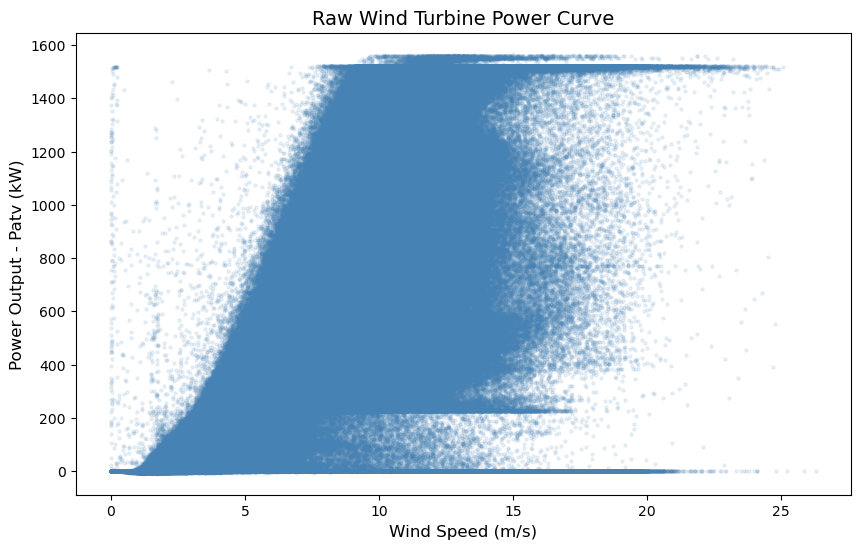

Notice the scattered points — those are bad readings we'll clean later!


In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/plots", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.scatter(df["Wspd"], df["Patv"], alpha=0.1, s=5, color='steelblue')
plt.xlabel("Wind Speed (m/s)", fontsize=12)
plt.ylabel("Power Output - Patv (kW)", fontsize=12)
plt.title("Raw Wind Turbine Power Curve", fontsize=14)
plt.savefig("01_raw_power_curve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Notice the scattered points — those are bad readings we'll clean later!")

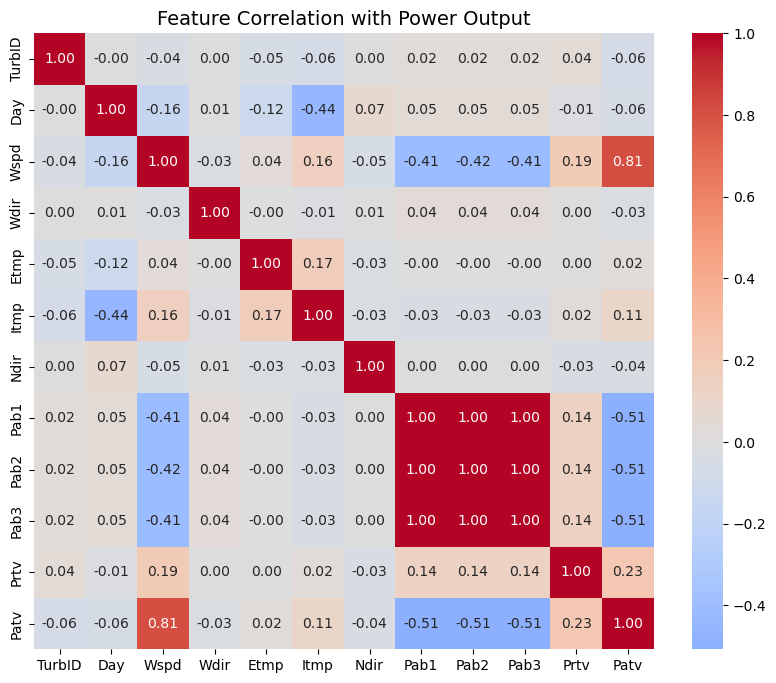


Correlation with Patv (power output):
Patv      1.000000
Wspd      0.812945
Prtv      0.233711
Itmp      0.106521
Etmp      0.017973
Wdir     -0.026436
Ndir     -0.035592
Day      -0.055268
TurbID   -0.064101
Pab3     -0.506833
Pab2     -0.507012
Pab1     -0.507240
Name: Patv, dtype: float64


In [16]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation with Power Output", fontsize=14)
plt.savefig("01_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation with Patv (power output):")
print(corr["Patv"].sort_values(ascending=False))